In [8]:
# necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [9]:
# 1. Load the Titanic dataset
df = sns.load_dataset("titanic")
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (891, 15)

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [10]:

# 2. Handle missing values
print("\nMissing values before handling:")
print(df.isnull().sum())


Missing values before handling:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [11]:
# Create a copy for preprocessing
df_clean = df.copy()

In [12]:
columns_to_drop = ['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town']
existing_columns = [col for col in columns_to_drop if col in df_clean.columns]
columns_not_found = [col for col in columns_to_drop if col not in df_clean.columns]

if columns_not_found:
    print(f"\n Warning: These columns were not found and will be skipped: {columns_not_found}")

if existing_columns:
    df_clean = df_clean.drop(columns=existing_columns)
    print(f"\n Dropped columns: {existing_columns}")

# Display remaining columns
print(f"\nRemaining columns after dropping: {df_clean.columns.tolist()}")

# Fill missing 'age' with median
if 'age' in df_clean.columns:
    df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())



 Dropped columns: ['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town']

Remaining columns after dropping: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [13]:
# Fill missing 'age' with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

In [14]:
# Fill missing 'embarked' with mode (most frequent value)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])


In [15]:
# Drop remaining rows with any missing values
df_clean = df_clean.dropna()

print("\nMissing values after handling:")
print(df_clean.isnull().sum())
print(f"\nDataset shape after cleaning: {df_clean.shape}")


Missing values after handling:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

Dataset shape after cleaning: (891, 9)


In [16]:
# Encode categorical columns
# Encode 'sex' (male=0, female=1)
le_sex = LabelEncoder()
df_clean['sex'] = le_sex.fit_transform(df_clean['sex'])

In [17]:
# Encode 'embarked' (S, C, Q)
le_embarked = LabelEncoder()
df_clean['embarked'] = le_embarked.fit_transform(df_clean['embarked'])


In [18]:
# Convert 'alone' from boolean to int
df_clean['alone'] = df_clean['alone'].astype(int)

print("\nEncoded dataset info:")
print(df_clean.head())


Encoded dataset info:
   survived  pclass  sex   age  sibsp  parch     fare  embarked  alone
0         0       3    1  22.0      1      0   7.2500         2      0
1         1       1    0  38.0      1      0  71.2833         0      0
2         1       3    0  26.0      0      0   7.9250         2      1
3         1       1    0  35.0      1      0  53.1000         2      0
4         0       3    1  35.0      0      0   8.0500         2      1


In [19]:
# Prepare features and target
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

In [20]:
# Select only numeric features for the model
numeric_columns = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
X = X[numeric_columns]

print("\nFeatures used:", X.columns.tolist())
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")



Features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
Feature matrix shape: (891, 8)
Target vector shape: (891,)


In [37]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 712
Test set size: 179


In [38]:
# Scale the features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [39]:
# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)


In [24]:
# Evaluate Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['Not Survived', 'Survived']))


LOGISTIC REGRESSION RESULTS

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



Text(0.5, 25.722222222222214, 'Predicted')

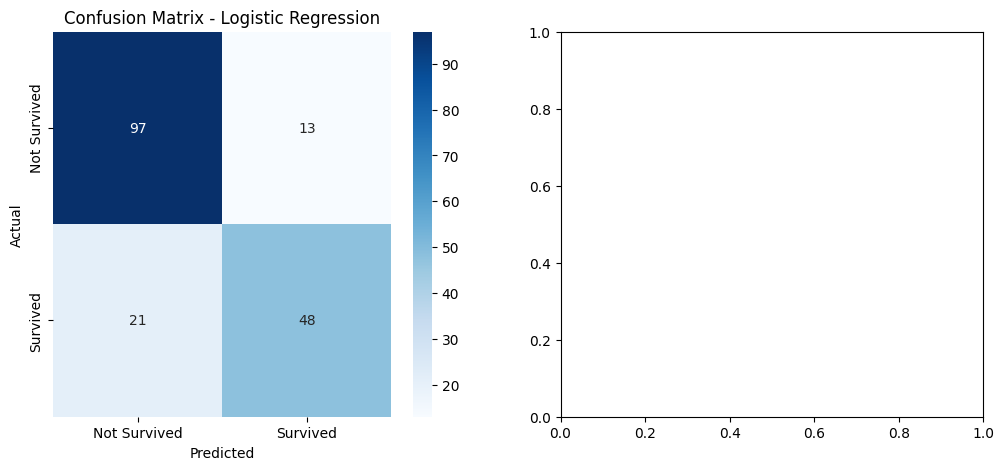

In [25]:
# Plot confusion matrix for Logistic Regression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
ax1.set_title('Confusion Matrix - Logistic Regression')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')


In [40]:
# Add accuracy score text
log_accuracy = accuracy_score(y_test, y_pred_log)
ax1.text(0.5, -0.15, f'Accuracy: {log_accuracy:.4f}', 
         transform=ax1.transAxes, ha='center', fontsize=12, weight='bold')

Text(0.5, -0.15, 'Accuracy: 0.8101')

In [27]:
# 5. Challenge: Also try KNN and compare
# Find best k value (optional improvement)
k_values = range(1, 21)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_scores.append(knn.score(X_test_scaled, y_test))

best_k = k_values[np.argmax(knn_scores)]
print(f"\nBest K value for KNN: {best_k} with accuracy: {max(knn_scores):.4f}")



Best K value for KNN: 13 with accuracy: 0.8156


In [41]:
# Train KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

# Also train with default k=5 for comparison
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)
y_pred_knn_default = knn_default.predict(X_test_scaled)

In [42]:
# Evaluate KNN
print("\n" + "="*60)
print("KNN RESULTS (Best K)")
print("="*60)
print(f"\nBest K value: {best_k}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Not Survived', 'Survived']))


KNN RESULTS (Best K)

Best K value: 13

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.90      0.86       110
    Survived       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



In [43]:
# Plot confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
ax2.set_title(f'Confusion Matrix - KNN (k={best_k})')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

knn_accuracy = accuracy_score(y_test, y_pred_knn)
ax2.text(0.5, -0.15, f'Accuracy: {knn_accuracy:.4f}', 
         transform=ax2.transAxes, ha='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [44]:

# 6. Detailed Comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN (k=5)', f'KNN (k={best_k})'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn_default),
        accuracy_score(y_test, y_pred_knn)
    ]
})

comparison_df['Accuracy'] = comparison_df['Accuracy'].map('{:.4f}'.format)
print(comparison_df.to_string(index=False))


MODEL COMPARISON
              Model Accuracy
Logistic Regression   0.8101
          KNN (k=5)   0.8045
         KNN (k=13)   0.8156


In [45]:
#Feature importance for Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION - FEATURE IMPORTANCE")
print("="*60)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))



LOGISTIC REGRESSION - FEATURE IMPORTANCE
 Feature  Coefficient
     sex    -1.254297
  pclass    -0.851244
     age    -0.478945
   sibsp    -0.424324
   alone    -0.286813
   parch    -0.187534
embarked    -0.162319
    fare     0.082861


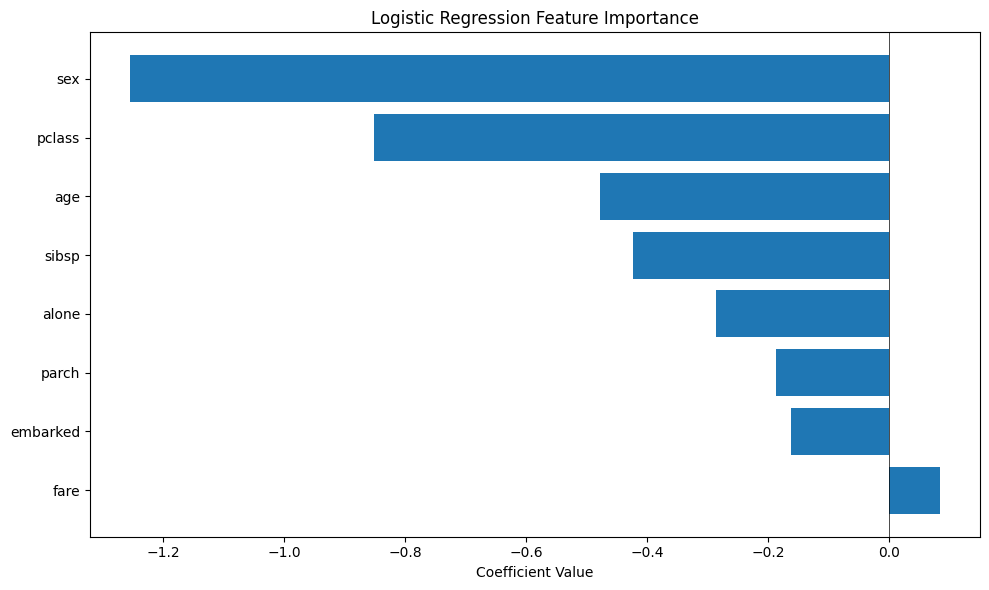

In [46]:
# Visualization of feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Importance')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



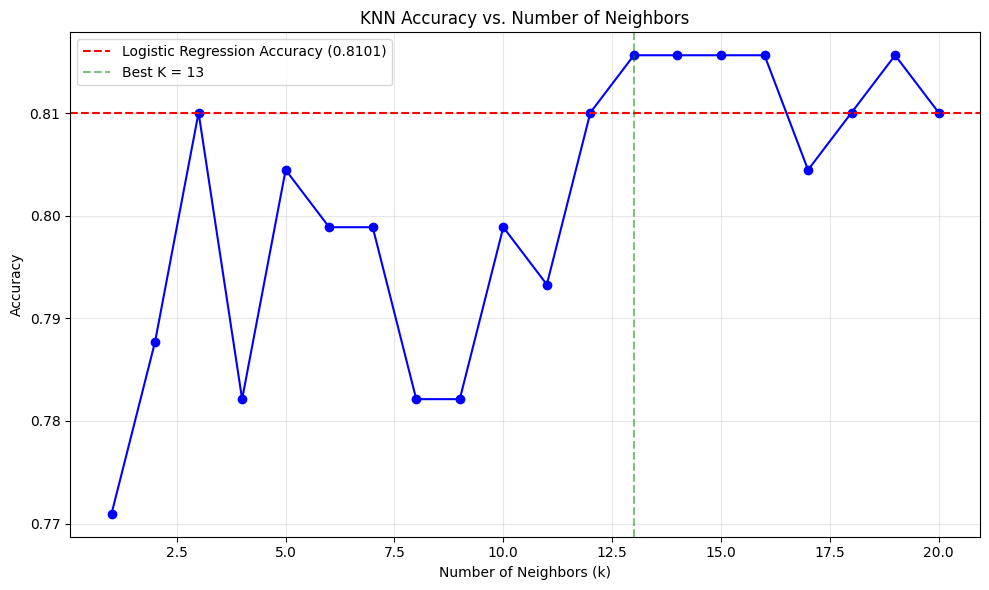

In [47]:
# KNN performance across different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_scores, 'bo-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.axhline(y=log_accuracy, color='r', linestyle='--', label=f'Logistic Regression Accuracy ({log_accuracy:.4f})')
plt.axvline(x=best_k, color='g', linestyle='--', alpha=0.5, label=f'Best K = {best_k}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
# Summary statistics
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Total samples: {len(df)}")
print(f"Samples after cleaning: {len(df_clean)}")
print(f"Survival rate in dataset: {y.mean():.2%}")

if log_accuracy > knn_accuracy:
    print(f"\n Logistic Regression performs better with {log_accuracy:.4f} accuracy vs {knn_accuracy:.4f}")
elif knn_accuracy > log_accuracy:
    print(f"\n KNN performs better with {knn_accuracy:.4f} accuracy vs {log_accuracy:.4f}")
else:
    print(f"\n Both models perform equally with {log_accuracy:.4f} accuracy")

print("\nKey Insights:")
print("1. 'sex' is the strongest predictor (female = higher survival chance)")
print("2. 'pclass' (passenger class) is also important (higher class = higher survival)")
print("3. Age and fare also contribute to survival prediction")


SUMMARY
Total samples: 891
Samples after cleaning: 891
Survival rate in dataset: 38.38%

 KNN performs better with 0.8156 accuracy vs 0.8101

Key Insights:
1. 'sex' is the strongest predictor (female = higher survival chance)
2. 'pclass' (passenger class) is also important (higher class = higher survival)
3. Age and fare also contribute to survival prediction
